# DAAAnalyzer_1.0_PlotDPOAEs.ipynb
Created by: JFranco | Created On: 26 NOV 2024 | Last Env: QISHA | Last Run Date: 20 JAN 2025

This Python notebook will read in the existing file that compiled DPOAE f2 thresholds for all subjects to
generate a plot. It will also output the groupby describe values for this run. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters for plotting
conditions = ["Pink","Blue","NonInj"]
pltOrder = conditions
colors = {pltOrder[0]:'mediumorchid',pltOrder[1]:'slateblue', pltOrder[2]:'black'}
legColors = ["mediumorchid","slateblue",'black']

In [2]:
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]

In [3]:
#                *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_008'
daaRun = '3'
daaType = '2 Wks Post Noise Exposure'

# Directories 
#   - Existing ones -
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/DAA/'
dirPrep = dirMain+prepID+'/'
dirData = dirPrep+'RawData/'
dirMD = dirPrep+'Metadata/'
dirDFs = dirPrep+"Results/1_CompiledMeasurements/"
dirDPOAEs = dirPrep+"Results/2_DPOAEPlotsByGroup/"

# Filenames
#    - Existing Ones - 
fnDPs = prepID+'.DPOAEf2Thresholds.DAA_'+daaRun+'.csv'
isoFile = 'IsoDP-'+daaRun+'-1.tsv'

#    - Ones that will be made - 
fnPltDP = prepID+'.DPOAEf2Thresholds.DAA_'+daaRun+'.png'
fnGBDPs = prepID+'.GroupDPOAEStats.DAA_'+daaRun+'.csv'

In [4]:
# *** LOAD DPOAE DATA **
# Sample metadata sheet that include animal and condition info
dfDPs = pd.read_csv(dirDFs+fnDPs, index_col=0)

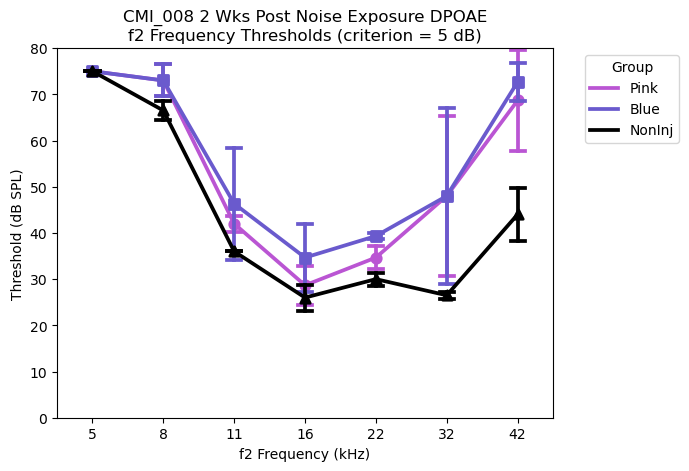

In [5]:
# *** SET PLOT SPECIFIC PARAMETERS ***
plot = "DPOAEs.DAA_"+daaRun
plottype = "PtPlt"
title = prepID+" "+daaType+" DPOAE\n"+"f2 Frequency Thresholds (criterion = 5 dB)"
hue = 'InjGroup'
x = "f2Freq_kHz"
y="Thresh_dBSPL"
xlab = "f2 Frequency (kHz)"
ylab = "Threshold (dB SPL)"
ymin = 0
ymax = 80

# *** MAKE PLOT ***
# Code for two styles of plots are shown below 
# Uncomment code below for an alternate plot style (i.e., points connected by a line at average with errorbars)
#ax = sns.lineplot(data=dfDPs,x=x, y=y, hue=hue,palette=colors)
ax = sns.pointplot(data=dfDPs,x=x, y=y, hue=hue,markers=["o","s","^"], linestyles=["-", "-","-"],
                   errorbar='sd', capsize=.2, palette=colors)

plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
leg = ax.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
ax.set_title(title)
ax.set(xlabel=xlab)
ax.set(ylabel=ylab)
ax.set_ylim((ymin, ymax))

# *** SAVE THE FIGURE ***
plt.savefig(dirDPOAEs+fnPltDP,  bbox_inches='tight', dpi = 300,format = 'png')

In [6]:
# *** CALCULATE AND SAVE GROUPBY DESCRIBE INFO ***
# Drop columns that are not needed for groupby stats
df = dfDPs.drop(['AnimalID','CMIID','DAA_Run','Sex'], axis=1)
grpDPs = df.groupby(['InjGroup', 'f2Freq_kHz'])
grpDPsStats = grpDPs.describe()
grpDPsStats.to_csv(dirDFs+fnGBDPs, index=True)
grpDPsStats

Thresh_dBSPL                                           \
                           count       mean        std   min    25%   50%   
InjGroup f2Freq_kHz                                                         
Blue     5                   3.0  75.000000   0.000000  75.0  75.00  75.0   
         8                   3.0  73.000000   3.464102  69.0  72.00  75.0   
         11                  3.0  46.333333  12.096832  37.0  39.50  42.0   
         16                  3.0  34.666667   7.371115  29.0  30.50  32.0   
         22                  3.0  39.333333   0.577350  39.0  39.00  39.0   
         32                  3.0  48.000000  19.000000  32.0  37.50  43.0   
         42                  3.0  72.666667   4.041452  68.0  71.50  75.0   
NonInj   5                   2.0  75.000000   0.000000  75.0  75.00  75.0   
         8                   2.0  66.500000   2.121320  65.0  65.75  66.5   
         11                  2.0  36.000000   0.000000  36.0  36.00  36.0   
         16                  2.0  26.000000   2.828427  24.0  25.00  26.0   
         22                  2.0  30.000000   1.414214  29.0  29.50  30.0   
         32                  2.0  26.500000   0.707107  26.0  26.25  26.5   
         42                  2.0  44.000000   5.656854  40.0  42.00  44.0   
Pink     5                   3.0  75.000000   0.000000  75.0  75.00  75.0   
         8                   3.0  73.000000   3.464102  69.0  72.00  75.0   
         11                  3.0  42.000000   1.732051  40.0  41.50  43.0   
         16                  3.0  28.666667   4.163332  24.0  27.00  30.0   
         22                  3.0  34.666667   2.516611  32.0  33.50  35.0   
         32                  3.0  48.000000  17.320508  28.0  43.00  58.0   
         42                  3.0  68.666667  10.969655  56.0  65.50  75.0   

                                  
                       75%   max  
InjGroup f2Freq_kHz               
Blue     5           75.00  75.0  
         8           75.00  75.0  
         11          51.00  60.0  
         16          37.50  43.0  
         22          39.50  40.0  
         32          56.00  69.0  
         42          75.00  75.0  
NonInj   5           75.00  75.0  
         8           67.25  68.0  
         11          36.00  36.0  
         16          27.00  28.0  
         22          30.50  31.0  
         32          26.75  27.0  
         42          46.00  48.0  
Pink     5           75.00  75.0  
         8           75.00  75.0  
         11          43.00  43.0  
         16          31.00  32.0  
         22          36.00  37.0  
         32          58.00  58.0  
         42          75.00  75.0